# Inviting exploration of CMIP data in ARCO formats

This example notebook helps to see different ways to optimize a CMIP data analysis by simply interfacing with zarr, or icechunk without having to rewrite the NetCDF source completely.

Example 1- Working with CMIP6 NetCDF in AWS directly (bucket: esgf-world)

Example 2- Working with CMIP6 Zarr in GCP  

Example 3- Working with CMIP6 NetCDF source but reaping benefits of Zarr through virtualizarr and icechunk


Issue https://github.com/jbusecke/esgf-virtual-zarr-data-access/issues/18

If you have any questions, please open an issue here https://github.com/jbusecke/esgf-virtual-zarr-data-access.


References:
https://virtualizarr.readthedocs.io/en/stable/index.html#quick-usage-example
https://github.com/aradhakrishnanGFDL/spear_flp_sandbox/
https://icechunk.io/en/stable/
https://esgf-world.s3.amazonaws.com/index.html
https://registry.opendata.aws/cmip6/
https://pangeo-data.github.io/pangeo-cmip6-cloud/overview.html

#Example-1  Working with CMIP6 NetCDF in AWS directly (bucket: esgf-world)

In [43]:
#%pip install s3fs

In [45]:
import s3fs
import xarray as xr
%matplotlib inline
fs_s3 = s3fs.S3FileSystem(anon=True)
s3path = 's3://esgf-world/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/tas_Amon_GFDL-CM4_historical_r1i1p1f1_gr1_185001-194912.nc'
remote_file_obj = fs_s3.open(s3path, mode='rb')

ds = xr.open_dataset(remote_file_obj, chunks={'time': 1})

ds

#Alternatively refer to intake-esm catalog based examples here https://github.com/aradhakrishnanGFDL/gfdl-aws-analysis/blob/master/examples/nino3_exercise.ipynb

<xarray.Dataset> Size: 249MB
Dimensions:    (lat: 180, bnds: 2, lon: 288, time: 1200)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * time       (time) object 10kB 1850-01-16 12:00:00 ... 1949-12-16 12:00:00
    height     float64 8B ...
Data variables:
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 249MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 19kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

# Example 2- Working with CMIP6 Zarr in GCP

In [ ]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import progress
from tqdm.autonotebook import tqdm
import intake
import fsspec
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
#%pip install intake-esm

In [ ]:
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


In [ ]:
# there is currently a significant amount of data for these runs
expts = ['historical', 'ssp245', 'ssp585']

query = dict(
    experiment_id=expts,
    table_id='Amon',
    variable_id=['tas'],
    member_id = 'r1i1p1f1',
    source_id = ['GFDL-CM4','GFDL-ESM4','CAMS-CSM1-0','IPSL-CM6A-LR']
)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
CAMS-CSM1-0,3,1,1
GFDL-CM4,3,1,1
GFDL-ESM4,3,1,1
IPSL-CM6A-LR,3,1,1


TIME dataset open

In [ ]:
#Quick timing test

# Display all columns
pd.set_option('display.max_columns', None)

# Display full column width (no truncation of cell content)
pd.set_option('display.max_colwidth', None) # Use None for pandas >= 1.0, use -1 for older versions

# Optional: Increase the display width to prevent line wrapping in the console
pd.set_option('display.width', 1000)

# Get the zstore path
zstore_path = col.df.loc[ (col.df['source_id'] == "GFDL-CM4") & (col.df['variable_id'] == "tas" ) ]["zstore"].iloc[0]



286 ms ± 24.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit

# Open the Zarr dataset using xr.open_zarr and fsspec
ds_test = xr.open_zarr(fsspec.get_mapper(zstore_path), consolidated=True,chunks={})
#print(ds_test["tas"].chunks)  #((600, 432), (180,), (288,))
ds_test["tas"].mean().compute()

1.45 s ± 164 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
def drop_all_bounds(ds):
    drop_vars = [vname for vname in ds.coords
                 if (('_bounds') in vname ) or ('_bnds') in vname]
    return ds.drop(drop_vars)

def open_dset(df):
    assert len(df) == 1
    ds = xr.open_zarr(fsspec.get_mapper(df.zstore.values[0]), consolidated=True)
    return drop_all_bounds(ds)

def open_delayed(df):
    return dask.delayed(open_dset)(df)

from collections import defaultdict
dsets = defaultdict(dict)

for group, df in col_subset.df.groupby(by=['source_id', 'experiment_id']):
    dsets[group[0]][group[1]] = open_delayed(df)

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
%time dsets_ = dask.compute(dict(dsets))[0]

/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.d

CPU times: user 494 ms, sys: 34.2 ms, total: 528 ms
Wall time: 2.78 s


/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)
/tmp/ipython-input-354912406.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return ds.drop(drop_vars)


In [ ]:
# calculate global means

def get_lat_name(ds):
    for lat_name in ['lat', 'latitude']:
        if lat_name in ds.coords:
            return lat_name
    raise RuntimeError("Couldn't find a latitude coordinate")

def global_mean(ds):
    lat = ds[get_lat_name(ds)]
    weight = np.cos(np.deg2rad(lat))
    weight /= weight.mean()
    other_dims = set(ds.dims) - {'time'}
    return (ds * weight).mean(other_dims)

In [ ]:
expt_da = xr.DataArray(expts, dims='experiment_id', name='experiment_id',
                       coords={'experiment_id': expts})

dsets_aligned = {}

for k, v in tqdm(dsets_.items()):
    expt_dsets = v.values()
    if any([d is None for d in expt_dsets]):
        print(f"Missing experiment for {k}")
        continue

    for ds in expt_dsets:
        print(ds)
        # Ensure the time coordinate is a datetime type for .dt accessor
        if ds.time.dtype == 'object':
            ds['time'] = ds.time.astype('datetime64[ns]')
        ds.coords['year'] = ds.time.dt.year

    # workaround for
    # https://github.com/pydata/xarray/issues/2237#issuecomment-620961663
    dsets_ann_mean = [v[expt].pipe(global_mean)
                             .swap_dims({'time': 'year'})
                             .drop('time')
                             .coarsen(year=12).mean()
                      for expt in expts]

    # align everything with the 4xCO2 experiment
    dsets_aligned[k] = xr.concat(dsets_ann_mean, join='outer',
                                 dim=expt_da)

  0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')


<xarray.Dataset> Size: 406MB
Dimensions:  (time: 1980, lat: 160, lon: 320)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float64 1kB -89.14 -88.03 -86.91 -85.79 ... 86.91 88.03 89.14
  * lon      (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
    height   float64 8B ...
Data variables:
    tas      (time, lat, lon) float32 406MB dask.array<chunksize=(600, 160, 320), meta=np.ndarray>
Attributes: (12/50)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          Standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  3025.0
    cmor_version:           3.4.0
    ...                     ...
    table_info:             Creation Date:(30 April 2019) MD5:cc2ae51c23960ce...
    title:                  CAMS-CSM1-0 output prepared for CMIP6
    tracking_id:            hdl:21.14100/9c0e170e-a3ad-48e7-a8a6-1a109ffe2df8
    variable_id:            tas
    vari

/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')


<xarray.Dataset> Size: 411MB
Dimensions:  (time: 1980, lat: 180, lon: 288, bnds: 2)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * bnds     (bnds) float64 16B 1.0 2.0
    height   float64 8B ...
Data variables:
    tas      (time, lat, lon) float32 411MB dask.array<chunksize=(600, 180, 288), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36500.0
    comment:                <null ref>
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/75e5c5a7-d7c4-4860-beb1-db454f25f13a...
    variable_id:            tas
    variant

/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')


<xarray.Dataset> Size: 163MB
Dimensions:  (time: 1980, lat: 143, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
  * lat      (lat) float32 572B -90.0 -88.73 -87.46 -86.2 ... 87.46 88.73 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 8B ...
Data variables:
    tas      (time, lat, lon) float32 163MB dask.array<chunksize=(600, 143, 144), meta=np.ndarray>
Attributes: (12/52)
    CMIP6_CV_version:       cv=6.2.3.5-2-g63b123e
    Conventions:            CF-1.7 CMIP-6.2
    EXPID:                  historical
    NCO:                    "4.6.0"
    activity_id:            CMIP
    branch_method:          standard
    ...                     ...
    table_id:               Amon
    title:                  IPSL-CM6A-LR model output prepared for CMIP6 / CM...
    tracking_id:            hdl:21.14100/285a3a27-0287-4e3b-8232-69ddc89cebef
    variable_id:            tas
    variant_l

/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')
/tmp/ipython-input-559938160.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  .drop('time')


In [ ]:
with progress.ProgressBar():
    dsets_aligned_ = dask.compute(dsets_aligned)[0]

[########################################] | 100% Completed | 19.05 s


In [ ]:
source_ids = list(dsets_aligned_.keys())
source_da = xr.DataArray(source_ids, dims='source_id', name='source_id',
                         coords={'source_id': source_ids})

big_ds = xr.concat([ds.reset_coords(drop=True)
                    for ds in dsets_aligned_.values()],
                    dim=source_da)

big_ds

/tmp/ipython-input-2886188115.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  big_ds = xr.concat([ds.reset_coords(drop=True)


<xarray.Dataset> Size: 26kB
Dimensions:        (source_id: 4, experiment_id: 3, year: 251)
Coordinates:
  * source_id      (source_id) <U12 192B 'CAMS-CSM1-0' ... 'IPSL-CM6A-LR'
  * experiment_id  (experiment_id) <U10 120B 'historical' 'ssp245' 'ssp585'
  * year           (year) float64 2kB 1.85e+03 1.851e+03 ... 2.099e+03 2.1e+03
Data variables:
    tas            (source_id, experiment_id, year) float64 24kB 287.2 ... 292.7
Attributes: (12/55)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          Standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  3025.0
    cmor_version:           3.4.0
    ...                     ...
    status:                 2019-10-25;created;by nhn2@columbia.edu
    axis:                   Y
    bounds:                 lat_bnds
    long_name:              Latitude
    standard_name:          latitude
    units:                  degrees_north

In [ ]:
df_all = big_ds.sel(year=slice(1900, 2100)).to_dataframe().reset_index()
df_all.head()

,source_id,experiment_id,year,tas
0,CAMS-CSM1-0,historical,1900.0,287.084974
1,CAMS-CSM1-0,historical,1901.0,287.201559
2,CAMS-CSM1-0,historical,1902.0,287.178181
3,CAMS-CSM1-0,historical,1903.0,286.582873
4,CAMS-CSM1-0,historical,1904.0,286.714936


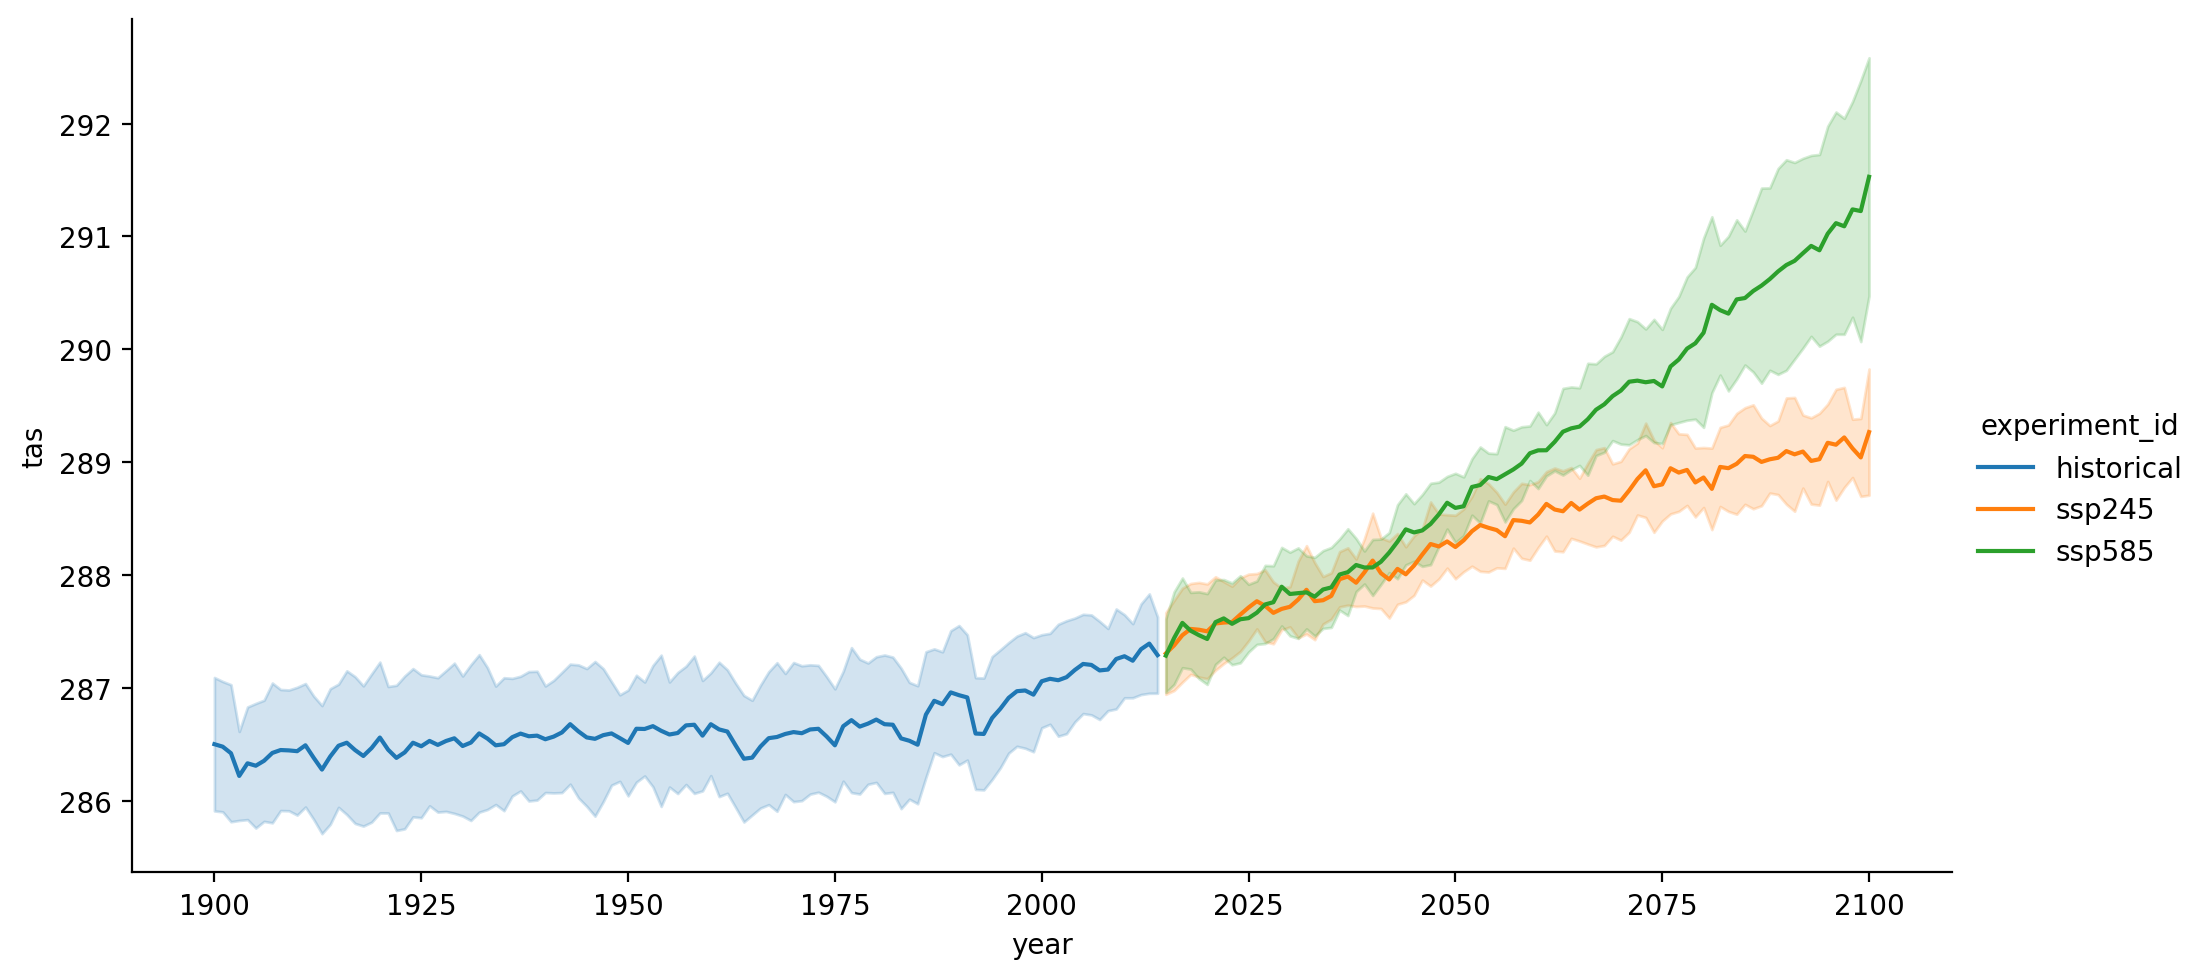

In [ ]:
sns.relplot(data=df_all,
            x="year", y="tas", hue='experiment_id',
            kind="line", errorbar="sd", aspect=2);

# Example 3- Working with CMIP6 NetCDF source but reaping benefits of Zarr through virtualizarr and icechunk




#Virtualizarr Test
Creating a virtual dataset with the source as NetCDF


Ref https://virtualizarr.readthedocs.io/en/stable/index.html#features

In [3]:
import xarray as xr
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from virtualizarr.registry import ObjectStoreRegistry
import icechunk, parquet

/tmp/ipython-input-587386662.py:5: DeprecationWarning: Importing ObjectStoreRegistry from VirtualiZarr is deprecated. Please use 'from obspec_utils.registry import ObjectStoreRegistry instead.
  from virtualizarr.registry import ObjectStoreRegistry


In [ ]:
#%pip install cftime
#You'll need this when you get to opening the dataset later

In [34]:
#%pip install obstore virtualizarr icechunk fastparquet parquet obstore

In [4]:
#Zarr can emit a lot of warnings about Numcodecs not being including in
#the Zarr version 3 specification yet -- let's suppress those.

import warnings
warnings.filterwarnings(
  "ignore",
  message="Numcodecs codecs are not in the Zarr version 3 specification*",
  category=UserWarning
)

Create ObjectStore and ObjectStore registry using Obstore

In [5]:
#We can use Obstore's obstore.store.from_url convenience method to create an
#ObjectStore that can fetch data from the specified URLs.

bucket = "s3://esgf-world" # Changed from s3://esgf-world.s3 to match the s3_base_url
path = "CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/tas_Amon_GFDL-CM4_historical_r1i1p1f1_gr1_185001-194912.nc"
url = f"{bucket}/{path}"
store = from_url(bucket, region="us-east-2", skip_signature=True)
#store = from_url(bucket, skip_signature=True)

#We also need to create an ObjectStoreRegistry
#that maps the URL structure to the ObjectStore.

In [6]:
registry = ObjectStoreRegistry({bucket: store})

Create a parser instance and create a virtual dataset by passing the URL,
parser, and registry to virtualizarr.open_virtual_dataset.  

In [9]:
parser = HDFParser()
vds = open_virtual_dataset(
  url=f"{bucket}/{path}",
  parser=parser,
  registry=registry,
  loadable_variables=[],
)
print(vds)

<xarray.Dataset> Size: 249MB
Dimensions:    (lat: 180, bnds: 2, lon: 288, time: 1200)
Coordinates:
    lat        (lat) float64 1kB ManifestArray<shape=(180,), dtype=float64, c...
    bnds       (bnds) float64 16B ManifestArray<shape=(2,), dtype=float64, ch...
    lon        (lon) float64 2kB ManifestArray<shape=(288,), dtype=float64, c...
    time       (time) float64 10kB ManifestArray<shape=(1200,), dtype=float64...
    height     float64 8B ManifestArray<shape=(), dtype=float64, chunks=()>
Data variables:
    lat_bnds   (lat, bnds) float64 3kB ManifestArray<shape=(180, 2), dtype=fl...
    lon_bnds   (lon, bnds) float64 5kB ManifestArray<shape=(288, 2), dtype=fl...
    tas        (time, lat, lon) float32 249MB ManifestArray<shape=(1200, 180,...
    time_bnds  (time, bnds) float64 19kB ManifestArray<shape=(1200, 2), dtype...
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:         

In [36]:
print(f"Original dataset size: {vds.nbytes} bytes")
print(f"Virtual dataset size: {vds.vz.nbytes} bytes")
#  loadable_variables=[]

Original dataset size: 248872056 bytes
Virtual dataset size: 115392 bytes


# Let's use the virtual data to explore icechunk, version-controlled!

In [25]:
import os
import shutil

storage_path = 'cmipeg-tas-metadata'
storage = icechunk.local_filesystem_storage(
    path=storage_path,
)

# Ensure the path is clean before creating the repository
if os.path.exists(storage_path):
    shutil.rmtree(storage_path)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(icechunk.VirtualChunkContainer("s3://esgf-world/", icechunk.s3_store(region="us-east-2")))
credentials = icechunk.containers_credentials({"s3://esgf-world/": icechunk.s3_credentials(anonymous=True)})
repo = icechunk.Repository.create(storage, config, credentials)

In [30]:
session = repo.writable_session("main")
vds.virtualize.to_icechunk(session.store, group='tas_data')

In [31]:
session.commit("CMIP6 First icechunk test for Amon/tas/GFDL-CM4 with subgroup")

'EYNDQNW6JF974A5S8Q20'

In [32]:
ds = xr.open_zarr(
    session.store,
    group='tas_data',
    zarr_version=3,
    consolidated=False,
    chunks={},
)

/tmp/ipython-input-4105601453.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(


In [33]:
ds

<xarray.Dataset> Size: 249MB
Dimensions:    (lat: 180, bnds: 2, time: 1200, lon: 288)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * time       (time) object 10kB 1850-01-16 12:00:00 ... 1949-12-16 12:00:00
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height     float64 8B ...
Data variables:
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    time_bnds  (time, bnds) object 19kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 249MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

In [37]:
ds.tas

<xarray.DataArray 'tas' (time: 1200, lat: 180, lon: 288)> Size: 249MB
dask.array<open_dataset-tas, shape=(1200, 180, 288), dtype=float32, chunksize=(1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 10kB 1850-01-16 12:00:00 ... 1949-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    long_name:      Near-Surface Air Temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    standard_name:  air_temperature
    interp_method:  conserve_order2
    original_name:  tas

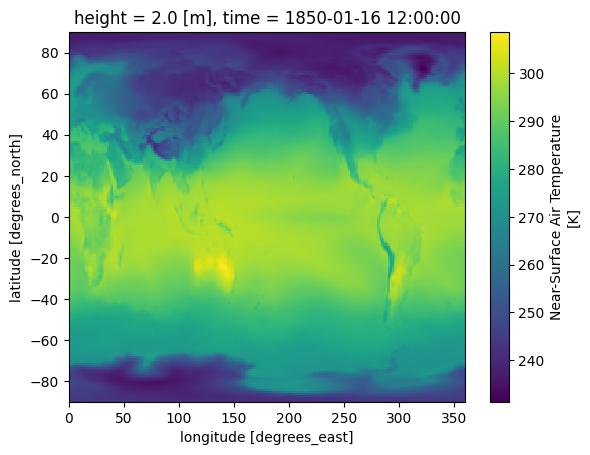

In [40]:
ds.tas.isel(time=0).plot()

In [47]:
#TODO show use of all time periods, all ensemble members for a given experiment, compute() time check,
#data search and use of catalog
#have a central environment and binder for reproducing this